In [6]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
transactions = pd.read_excel(r"D:\All data\QVI_transaction_data.xlsx")
transactions.head(3)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9


In [28]:
transactions .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [34]:
transactions.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [36]:
transactions.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='object')

In [38]:
transactions.columns = transactions.columns.str.strip().str.lower()

In [42]:
transactions.head(3)

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_name,prod_qty,tot_sales
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9


In [44]:
transactions["date"] = pd.to_datetime(transactions["date"])

In [46]:
transactions.columns

Index(['date', 'store_nbr', 'lylty_card_nbr', 'txn_id', 'prod_nbr',
       'prod_name', 'prod_qty', 'tot_sales'],
      dtype='object')

In [48]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            264836 non-null  datetime64[ns]
 1   store_nbr       264836 non-null  int64         
 2   lylty_card_nbr  264836 non-null  int64         
 3   txn_id          264836 non-null  int64         
 4   prod_nbr        264836 non-null  int64         
 5   prod_name       264836 non-null  object        
 6   prod_qty        264836 non-null  int64         
 7   tot_sales       264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.2+ MB


In [52]:
transactions.duplicated().sum()

1

In [54]:
transactions. drop_duplicates(inplace = True)

In [56]:
transactions.duplicated().sum()

0

In [88]:
 #Remove outliers in total sales
Q1 = transactions['tot_sales'].quantile(0.25)
Q3 = transactions['tot_sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
transactions = transactions[(transactions['tot_sales'] >= lower) & (transactions['tot_sales'] <= upper)]

In [114]:
customer = pd.read_csv(r"C:\Users\ArtiR\Downloads\QVI_purchase_behaviour.csv")
customer.head(3)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget


In [116]:
customer.head(3)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget


In [118]:
customer.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [120]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [122]:
customer.duplicated().sum()

0

In [124]:
customer.drop_duplicates(inplace = True)

In [126]:
customer.duplicated().sum()

0

In [128]:
customer .columns

Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='object')

In [130]:
customer.columns = customer.columns.str.strip().str.lower()

In [132]:
customer.head(3)

,lylty_card_nbr,lifestage,premium_customer
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget


In [134]:
customer.describe()

,lylty_card_nbr
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [136]:
# merged the transactions and customer data tables 
merged_df = pd.merge(transactions,customer,how= "inner", on = "lylty_card_nbr")

In [142]:
merged_df.head(3)

,date,store_nbr,lylty_card_nbr,txn_id,prod_nbr,prod_name,prod_qty,tot_sales,lifestage,premium_customer
0,1970-01-01 00:00:00.000043390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,1970-01-01 00:00:00.000043599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,1970-01-01 00:00:00.000043605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget


In [146]:
 # Define Metrics
total_sales = merged_df['tot_sales'].sum()
sales_by_product = merged_df.groupby('prod_name')['tot_sales'].sum().sort_values(ascending=False)
sales_by_store = merged_df.groupby('store_nbr')['tot_sales'].sum()



In [156]:
#Total sales
total_sales = merged_df["tot_sales"].sum()
total_sales

1921750.9500000007

In [160]:
# Top 5 products 
top_products = merged_df.groupby("prod_name")["tot_sales"].sum().nlargest(5)
top_products

prod_name
Dorito Corn Chp     Supreme 380g            38918.75
Smiths Crnkle Chip  Orgnl Big Bag 380g      35907.40
Smiths Crinkle Chips Salt & Vinegar 330g    34570.50
Smiths Crinkle      Original 330g           34040.40
Kettle Mozzarella   Basil & Pesto 175g      33933.60
Name: tot_sales, dtype: float64

In [164]:
#Top customer segments
segment_sales = merged_df.groupby('lifestage')['tot_sales'].sum()
segment_sales

lifestage
MIDAGE SINGLES/COUPLES    183582.95
NEW FAMILIES               50253.10
OLDER FAMILIES            349945.25
OLDER SINGLES/COUPLES     399965.15
RETIREES                  364567.65
YOUNG FAMILIES            314096.85
YOUNG SINGLES/COUPLES     259340.00
Name: tot_sales, dtype: float64

In [172]:
 #Sales by pack size
pack_sales = merged_df.groupby('prod_qty')['tot_sales'].sum()
pack_sales

prod_qty
1     102220.00
2    1811769.20
3       3816.45
4       2517.40
5       1427.90
Name: tot_sales, dtype: float64

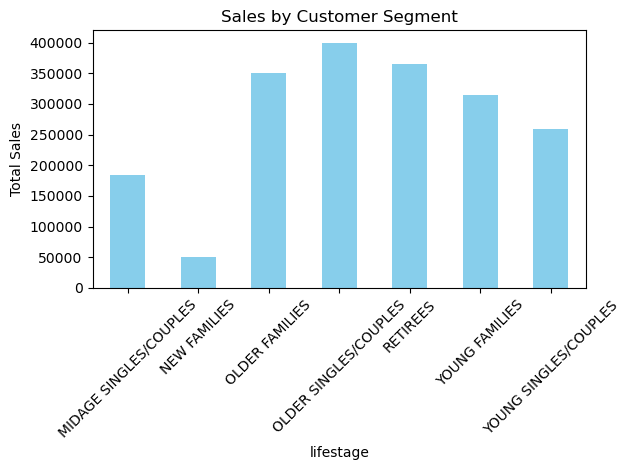

In [174]:

# Sales by customer segment
segment_sales.plot(kind='bar', color='skyblue', title='Sales by Customer Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

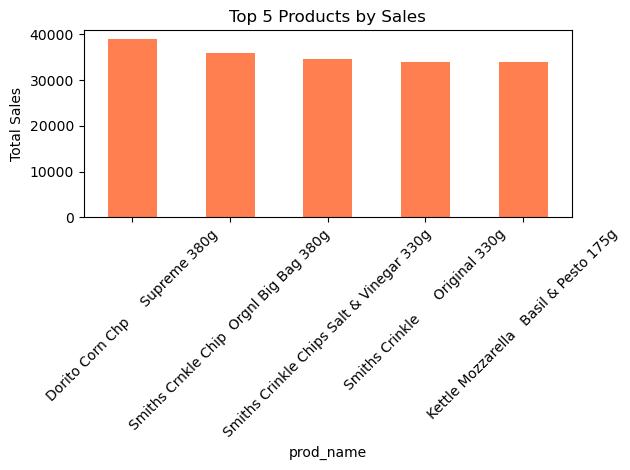

In [176]:
# Top products by sales
top_products.plot(kind='bar', color='coral', title='Top 5 Products by Sales')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

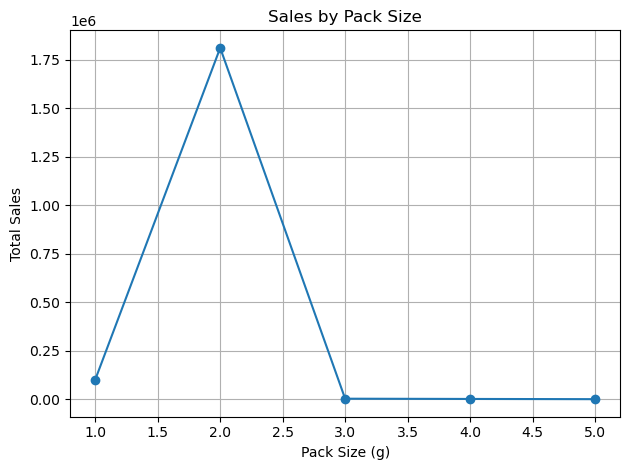

In [178]:
# Sales by pack size
pack_sales.plot(kind='line', marker='o', title='Sales by Pack Size')
plt.ylabel('Total Sales')
plt.xlabel('Pack Size (g)')
plt.grid()
plt.tight_layout()
plt.show()

C:\Users\ArtiR\AppData\Local\Temp\ipykernel_2564\768047677.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = merged_df.resample('M', on='date')['tot_sales'].sum()
C:\Users\ArtiR\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


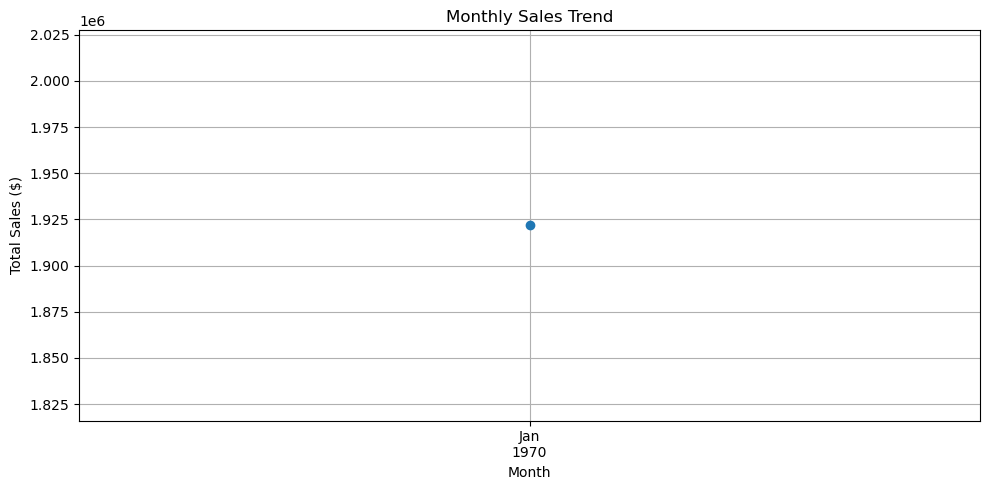

In [180]:
# Group sales by month
monthly_sales = merged_df.resample('M', on='date')['tot_sales'].sum()

# Plot
monthly_sales.plot(kind='line', marker='o', figsize=(10,5), title='Monthly Sales Trend')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.grid(True)
plt.tight_layout()
plt.show()


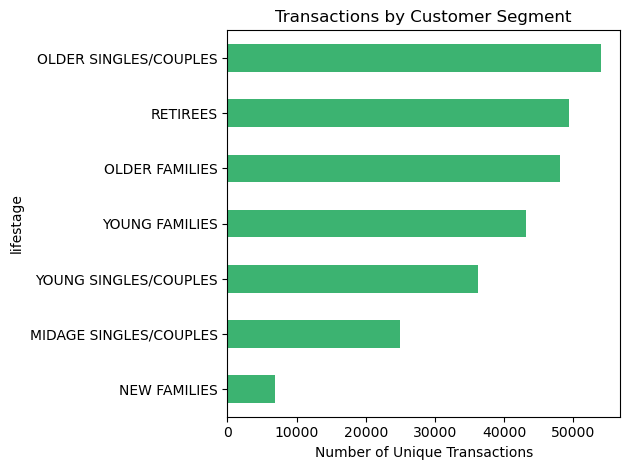

In [182]:
txn_by_segment = merged_df.groupby('lifestage')['txn_id'].nunique()

# Plot
txn_by_segment.sort_values().plot(kind='barh', color='mediumseagreen', title='Transactions by Customer Segment')
plt.xlabel('Number of Unique Transactions')
plt.tight_layout()
plt.show()


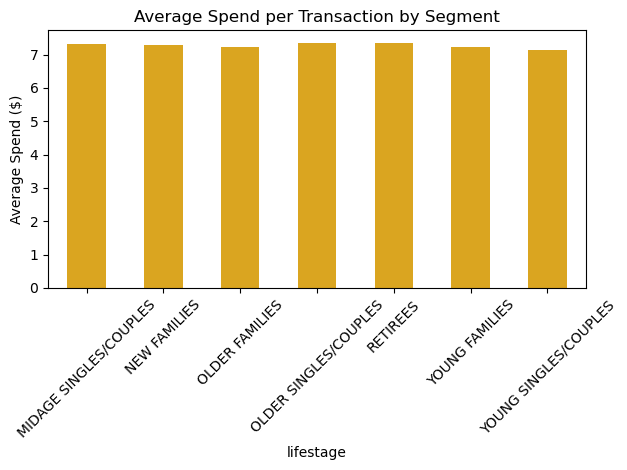

In [184]:
avg_spend = merged_df.groupby('lifestage')['tot_sales'].mean()

avg_spend.plot(kind='bar', color='goldenrod', title='Average Spend per Transaction by Segment')
plt.ylabel('Average Spend ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


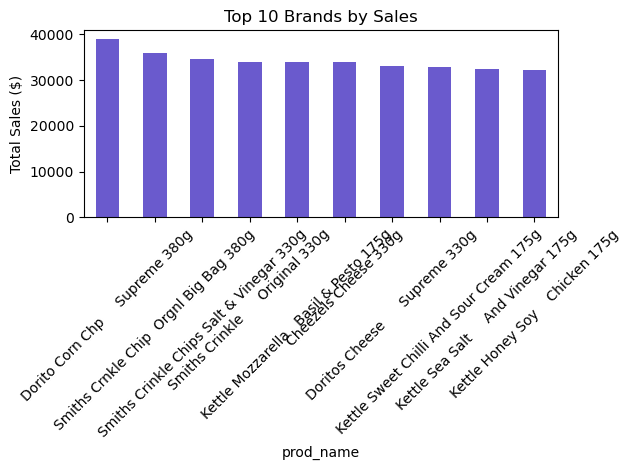

In [186]:
brand_sales = merged_df.groupby('prod_name')['tot_sales'].sum().nlargest(10)

brand_sales.plot(kind='bar', color='slateblue', title='Top 10 Brands by Sales')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


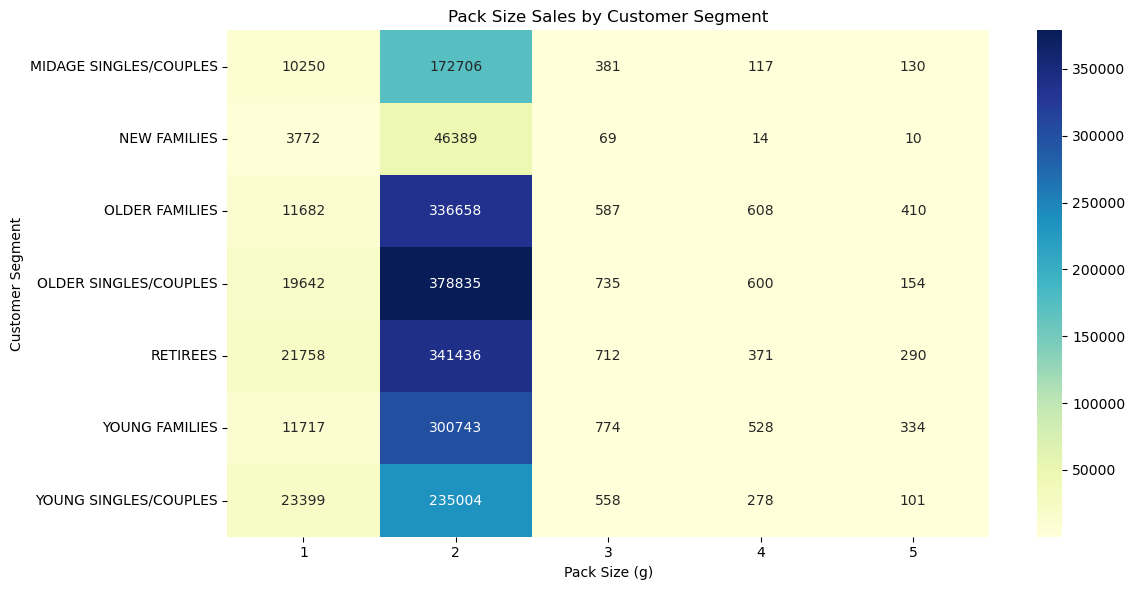

In [192]:
# pack size perference by segment
import seaborn as sns

pack_segment = merged_df.pivot_table(values='tot_sales', index='lifestage', columns='prod_qty', aggfunc='sum', fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(pack_segment, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Pack Size Sales by Customer Segment')
plt.xlabel('Pack Size (g)')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()


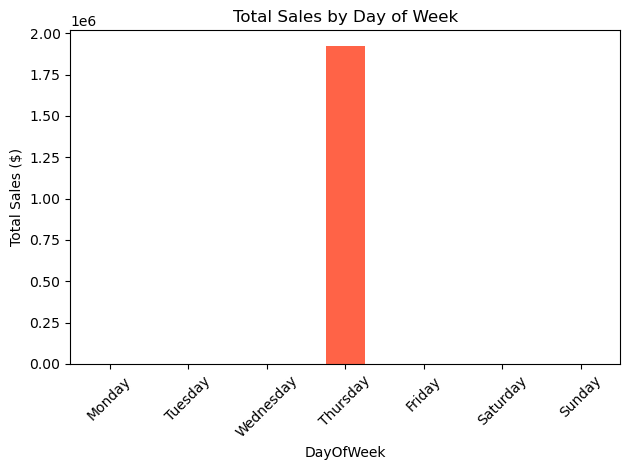

In [198]:
#sales by day of week
merged_df['DayOfWeek'] = merged_df['date'].dt.day_name()
dow_sales = merged_df.groupby('DayOfWeek')['tot_sales'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

dow_sales.plot(kind='bar', color='tomato', title='Total Sales by Day of Week')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
